# <u>**Trabajo Práctico N°3: Template Matching y Características Locales**</u>

- Visión por Computadora **[TA146]** - 1°C 2026

- Chechko, Víctor Nicolás **[110.901]**

- [Enunciado](https://github.com/maximdorogov/fundamentos-de-vision-fiuba/blob/main/trabajos_practicos/tp3/tp_3_enunciado.png).

In [1]:
# Imports.

import os
import requests
import numpy as np
import cv2

from matplotlib import pyplot as plt

In [2]:
# Carga de las imágenes a utilizar.

img_list = ['images/coca_logo_1.png', 'images/coca_logo_2.png','images/coca_multi.png', 'images/coca_retro_1.png',
            'images/coca_retro_2.png', 'images/COCA-COLA-LOGO.jpg', 'images/logo_1.png', 'template/pattern.png']

base_url = 'https://raw.githubusercontent.com/maximdorogov/fundamentos-de-vision-fiuba/main/trabajos_practicos/tp3/'

# Obtenemos las imágenes desde el repositorio si alguna falta o no estamos trabajando localmente sino, por ejemplo, en Colab.

for img_file in img_list:
    if not os.path.exists(img_file):
        dir_name = os.path.dirname(img_file)

        if dir_name:
            os.makedirs(dir_name, exist_ok=True)

        img = requests.get(base_url + img_file)
        with open(img_file, "wb") as file:
            file.write(img.content)

In [3]:
# Función que muestra una imagen con pyplot.

def plt_imshow(img, title=None, cmap=None):
    plt.imshow(img, cmap)
    if title != None:
        plt.title(title)
    plt.axis('off')
    plt.show()

## **1.** Detección Única con Template Matching

El objetivo de este trabajo práctico es la detección automática de instancias de un template o plantilla consistente en un logo de Coca Cola sobre una serie de imágenes que también poseen dicho logo.

<br>

La idea más básica para cumplir con esto es aplicar **template matching** entre la plantilla y cada imagen en cuestión. Para ello, se puede usar la función `cv2.matchTemplate`. Este método funciona desplazando el template, visto como matriz, a lo largo de la imagen, y realizando una operación que devuelve un valor relacionado con la similitud en la ubicación analizada. Esto genera una nueva matriz o imagen de salida más pequeña cuyos elementos están dados por dicha métrica de similitud. Como operación, vamos a emplear el método `cv2.TM_CCORR_NORMED` (correlación normalizada), que realiza:

<br>

$$
R(x,y) = \frac{\sum_{x',y'}\ T(x',y')\cdot I(x+x',y+y')}{\sqrt{\sum_{x',y'}\ T^2(x',y')\cdot \sum_{x',y'}\ I^2(x+x',y+y')}}
$$

<br>

Donde $T$ es el template, $I$ la imagen, y $(x,y)$ la posición en píxeles. El máximo de $R(x,y)$ (según lo define OpenCV) será el punto donde se cree que se ubica la esquina superior izquierda de la instancia detectada con mayor exactitud. Al ser un coeficiente normalizado, se garantiza que $0\leq R(x,y)\leq 1$.

<br>

El principal problema de este enfoque es que falla si el tamaño de la plantilla no está aproximadamente adaptado al tamaño de la instancia en la imagen, es decir, no hay invarianza a escala. En la prueba posterior se empleará `cv2.resize` sobre el template para asegurar esta condición.

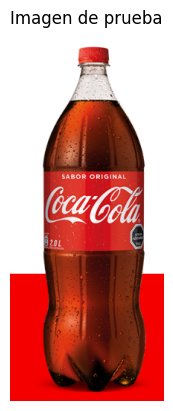

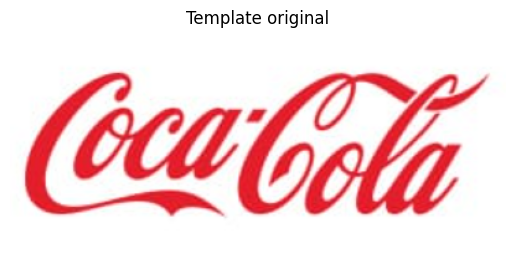

In [4]:
# Mostramos una imagen de prueba y el template.

img_test = cv2.imread('images/coca_logo_1.png', cv2.IMREAD_COLOR)
plt_imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB), "Imagen de prueba")

print("")

img_template = cv2.imread('template/pattern.png', cv2.IMREAD_COLOR)
plt_imshow(cv2.cvtColor(img_template, cv2.COLOR_BGR2RGB), "Template original")

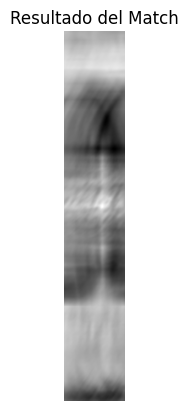

In [5]:
# Pasamos la imagen de prueba a espacio monocromático.
img_test_gray = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)

# Hacemos lo mismo con el template. Además, creamos una versión con
# la intensidad invertida, útil para la mayoría de detecciones.
img_template_gray = cv2.cvtColor(img_template, cv2.COLOR_BGR2GRAY)
img_template_gray_neg = cv2.bitwise_not(img_template_gray)

# Template con tamaño adaptado para que la detección sea correcta
# en la imagen de prueba.
img_template_gray_neg_resized = cv2.resize(img_template_gray_neg, (136, 60))

# Probamos a hacer template matching para la imagen de prueba.
# Usamos el método 'cv.TM_CCORR_NORMED'.
template_match_res = cv2.matchTemplate(img_test_gray, img_template_gray_neg_resized, cv2.TM_CCORR_NORMED)

# Mostramos el resultado del match.
plt_imshow(template_match_res, "Resultado del Match", cmap='gray')

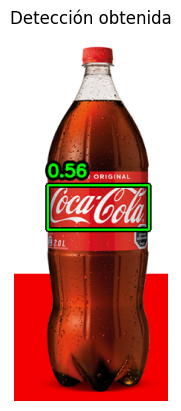

In [6]:
# Ancho y alto del template.
h_template, w_template = img_template_gray_neg_resized.shape

# Encontramos los mínimos y máximos del resultado.
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(template_match_res)
top_left = max_loc # Para el caso de 'cv.TM_CCORR_NORMED', se toma al máximo como esquina sup. izq.
bottom_right = (top_left[0] + w_template, top_left[1] + h_template) # Se define la esquina inf. derecha.

max_ccorr_normed = template_match_res[max_loc[1], max_loc[0]]

img_detection = img_test.copy()

# Dibujo del rectángulo sobre la detección (con contorno).
cv2.rectangle(img_detection, top_left, bottom_right, (0, 0, 0), 6)
cv2.rectangle(img_detection, top_left, bottom_right, (0, 255, 0), 2)

# Dibujo del texto con el valor (con contorno).
text = f"{max_ccorr_normed:.2f}"
cv2.putText(img_detection, text, (top_left[0], top_left[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 0, 0), 10, cv2.LINE_AA)
cv2.putText(img_detection, text, (top_left[0], top_left[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2, cv2.LINE_AA)

# Se muestra el resultado.
plt_imshow(cv2.cvtColor(img_detection, cv2.COLOR_BGR2RGB), "Detección obtenida")

Como se puede ver, la detección obtenida fue correcta, siendo el valor de la correlación normalizada que se obtuvo $0.56$; el mismo da una idea de la certeza o exactitud de la detección.

<br>

A continuación, a modo de detectar una única instancia en cada imagen, se repite el proceso, con el inconveniente de tener que adaptar el tamaño del template en cada ocasión, como ya se mencionó.

<br>

Para no contradecir el concepto de "detección automática", se podría hacer el proceso para una serie de $N$ dimensiones posibles distintas (en pasos fijos o variables) e ir almacenando las imágenes de correlación, para luego quedarnos con el máximo absoluto. La implementación posterior, sin embargo, no hace esto y supone que ya se conocen los tamaños de los objetos a detectar en cada imagen.

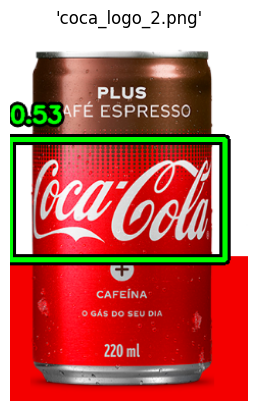

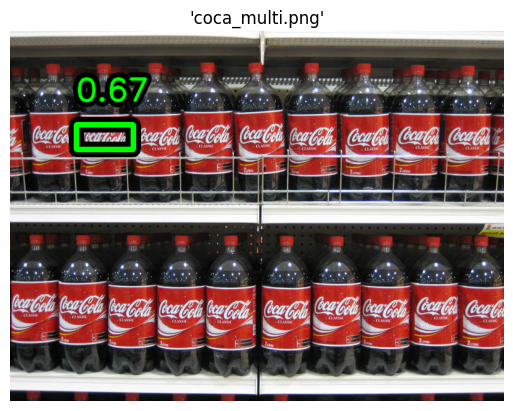

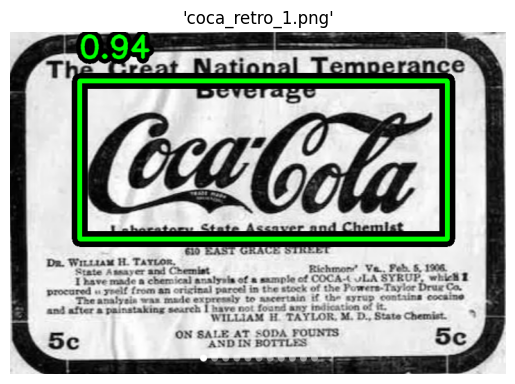

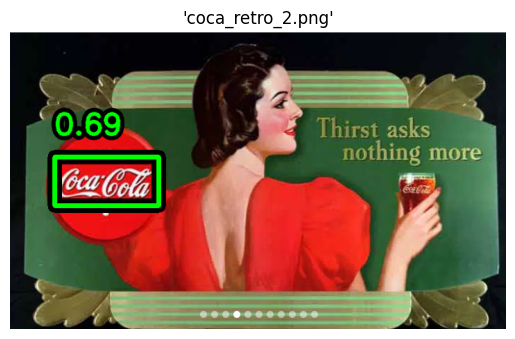

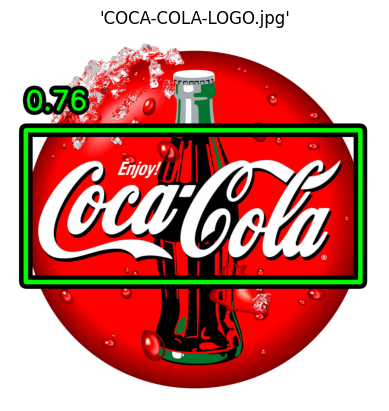

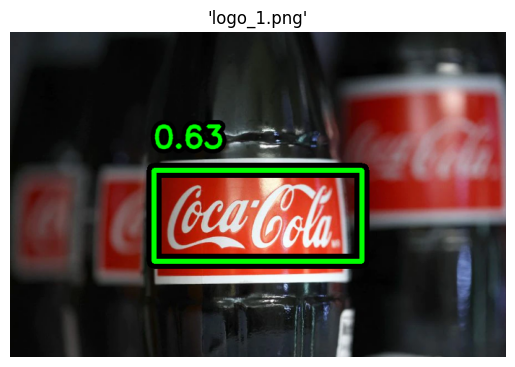

In [7]:
# Lista con los tamaños de template adaptados para cada imagen.
template_adaptation = [(210, 118), (92, 40), (530, 228), (150, 70), (1256, 570), (288, 126)]

# Iteramos sobre cada imagen restante y tamaño del template.
# En el caso de 'coca_retro_1' se usa el template no invertido.
for idx, img_name in enumerate(img_list[1:-1]):
    img = cv2.imread(img_name, cv2.IMREAD_COLOR)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    new_size = template_adaptation[idx]

    if img_name == 'images/coca_retro_1.png':
        template = img_template_gray.copy()
    else:
        template = img_template_gray_neg.copy()

    template_resized = cv2.resize(template, new_size)

    # Dimensiones.
    h_img, w_img = img_gray.shape
    h_template, w_template = template_resized.shape
    diag_img = int(np.sqrt(w_img**2 + h_img**2))

    # Template matching.
    template_match_res = cv2.matchTemplate(img_gray, template_resized, cv2.TM_CCORR_NORMED)

    # Hallazgo del máximo.
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(template_match_res)
    max_ccorr_normed = template_match_res[max_loc[1], max_loc[0]]

    # Bounding box.
    top_left = max_loc
    bottom_right = (top_left[0] + w_template, top_left[1] + h_template)

    img_detection = img.copy()

    # Dibujo del rectángulo sobre la detección (con contorno).
    cv2.rectangle(img_detection, top_left, bottom_right, (0, 0, 0), int(diag_img / 40))
    cv2.rectangle(img_detection, top_left, bottom_right, (0, 255, 0), int(diag_img / 130))

    # Dibujo del texto con el valor (con contorno).
    text = f"{max_ccorr_normed:.2f}"
    cv2.putText(img_detection, text, (top_left[0], top_left[1] - int(diag_img / 25)), cv2.FONT_HERSHEY_SIMPLEX, diag_img / 600, (0, 0, 0), int(diag_img / 50), cv2.LINE_AA)
    cv2.putText(img_detection, text, (top_left[0], top_left[1] - int(diag_img / 25)), cv2.FONT_HERSHEY_SIMPLEX, diag_img / 600, (0, 255, 0), int(diag_img / 200), cv2.LINE_AA)

    plt_imshow(cv2.cvtColor(img_detection, cv2.COLOR_BGR2RGB), f"'{img_name[7:]}'")

    print("")

Se observa que, con el enfoque llevado a cabo, las detecciones resultaron correctas en cada imagen.

## **2.** Detección Múltiple con SIFT

A continuación se probará a hacer las detecciones con **SIFT** (Scale-Invariant Feature Transform), un algoritmo de visión clásica que extrae las características locales de una imagen y construye un descriptor para ellas.

<br>

Comparando estas características locales o puntos clave (*keypoints*) es posible encontrar una correspondencia entre varias imágenes cuando los descriptores son similares, de forma que también se puede lograr el match entre una plantilla y una imagen mediante esta vía, contando con la ventaja de que el método posee invarianza a escala y rotación, y robustez frente a cambios leves de iluminación o perspectiva.

<br>

Se crea para ello un objeto `sift` para obtener los keypoints y descriptores en ambas imágenes, y luego un objeto `bf` (*brute-force matcher*) para efectuar la correspondencia. La aplicación de un `knnMatch` junto con el test del ratio de Lowe ayuda a eliminar correspondencias falsas.

### Prueba de SIFT con una Imagen con una Única Instancia.

Keypoints en el template: 129
Keypoints en la imagen de prueba: 3892
Cantidad de matches buenos: 29 



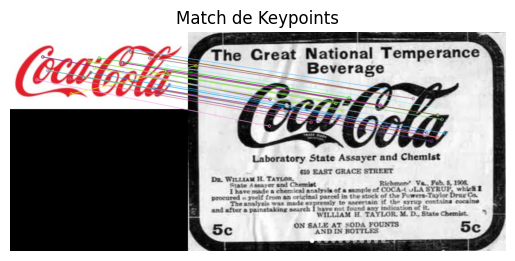

In [8]:
img_retro = cv2.imread('images/coca_retro_1.png', cv2.IMREAD_COLOR)
img_retro_gray = cv2.cvtColor(img_retro, cv2.COLOR_BGR2GRAY)

# Creación del objeto SIFT y detección de keypoints.
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img_template_gray, None)
kp2, des2 = sift.detectAndCompute(img_retro_gray, None)

print("Keypoints en el template:", len(kp1))
print("Keypoints en la imagen de prueba:", len(kp2))

# BFMatcher.
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Cantidad de matches buenos:", len(good_matches), "\n")

img_keypoints = cv2.drawMatchesKnn(img_template, kp1, img_retro, kp2, [good_matches], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt_imshow(cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB), "Match de Keypoints")

Se puede observar que la correspondencia de keypoints entre ambas imágenes es buena, por lo que esto alcanzaría para hacer una deteccción válida y definir una bounding box sobre la misma.

### Prueba de SIFT con una Imagen con Múltiples Instancias

Keypoints en el template: 129
Keypoints en la imagen de prueba: 4207
Cantidad de matches buenos: 10 



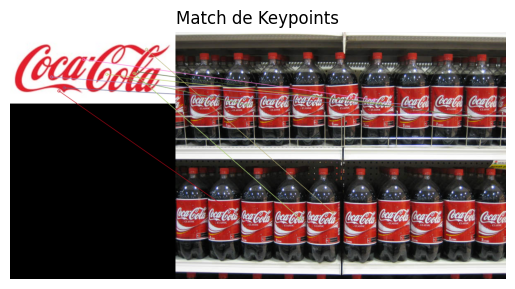

In [9]:
img_multi = cv2.imread('images/coca_multi.png', cv2.IMREAD_COLOR)
img_multi_gray = cv2.cvtColor(img_multi, cv2.COLOR_BGR2GRAY)

kp1, des1 = sift.detectAndCompute(img_template_gray_neg, None)
kp2, des2 = sift.detectAndCompute(img_multi_gray, None)

print("Keypoints en el template:", len(kp1))
print("Keypoints en la imagen de prueba:", len(kp2))

matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in matches:
    if m.distance < 0.8 * n.distance:
        good_matches.append(m)

print("Cantidad de matches buenos:", len(good_matches), "\n")

img_keypoints = cv2.drawMatchesKnn(img_template, kp1, img_multi, kp2, [good_matches], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt_imshow(cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB), "Match de Keypoints")

El problema que surge al haber varios logos en la imagen es que la correspondencia entre keypoints pierde la coherencia del caso anterior, ocurriendo que los puntos correspondidos pueden formar parte de distintas instancias. Esto lleva a que, si se quiere seguir con el enfoque de detectar con SIFT, se tenga que pensar en una solución que, de cierta forma, aisle cada instancia antes de efectuar la correspondencia.

### Solución Propuesta

La solución que se propone parte de la premisa de que, si bien los keypoints están distribuidos entre varios objetos en la imagen, cada keypoint individualmente, o al menos el que está asociado al match más confiable, pertenece a una instancia particular. La idea será entonces centrar un círculo de determinado radio sobre el keypoint y reintentar el match. Un posible algoritmo de este tipo se ve representado por el siguiente pseudocódigo:


```
funcion(template, imagen, intentos maximos, radio del círculo R):
  imagen_x = imagen
  imagen_procesada = imagen
  intentos restantes = intentos maximos
  detecciones = [] # Lista a ir populando con las detecciones.

  Por siempre:
    Matchear template con imagen_x

    Si el match es malo:
      Si intentos restantes > 1:
        intentos restantes--
        imagen_x = mascara circular de radio R sobre el "mejor keypoint"
      De lo contrario:
        Salir de la función y devolver detecciones # Ya no quedan instancias a detectar.
    
    De lo contrario si el match es bueno:
      Guardar métrica de certeza y bounding box en la lista de detecciones
      imagen_procesada = imagen_procesada - la detección
      imagen_x = imagen_procesada
      intentos restantes = intentos maximos
```

<br>

Para garantizar que no se detecte el mismo objeto dos veces, se opta por eliminar la región asociada a cada detección a medida que se vayan realizando.

<br>

El modo en que se determina si una determinada correspondencia es coherente es a través de una homografía con RANSAC. `cv2.findHomography` intenta hallar una matriz de transformación $H$ que describe como pasan los puntos de una imagen origen a una imagen destino, el vector `mask` que devuelve, además, tiene una máscara de unos para aquellos matches que se determinaron como válidos y ceros para aquellos que no; a la cantidad de matches válidos que sobrevivieron se los llama **inliers**, y el cociente entre la cantidad de inliers y cantidad de correspondencias originales, con un valor entre 0 y 1, da una idea de la precisión de la homografía o correspondencia.

<br>

Por último, se usa `cv2.perspectiveTransform` para proyectar el template sobre la imagen de acuerdo a la matriz de transformación $H$ hallada en la homografía, pudiéndose definir una bounding box rectangular que contenga dicha forma proyectada como indicador visual de la detección (si sabemos que los objetos pueden estar rotados, conviene emplear *oriented bounding boxes*).

In [10]:
# Nota: no se implementa control de errores por si algún paso falla o algún parámetro
# especificado es incoherente, simplemente se buscó que funcione.

def sift_object_detector(template, img, max_tries, circle_radius, lowe_ratio=0.75, margin_div=0):
    current_img = img.copy()
    processed_img = img.copy()
    tries_left = max_tries
    detections = []
    correct_detection = True # Flag "global".

    sift = cv2.SIFT_create()
    bf = cv2.BFMatcher()

    h_img, w_img = img.shape # Dimensiones de la imagen original.
    h_template, w_template = template.shape # Dimensiones del template.

    # Alcanza con calcular los keypoints del template una única vez.
    kp1, des1 = sift.detectAndCompute(template, None)

    while(True):
        # Hacer match del template con current_img.
        kp2, des2 = sift.detectAndCompute(current_img, None)
        matches = bf.knnMatch(des1, des2, k=2)
        good_matches = []
        for m, n in matches:
            if m.distance < lowe_ratio * n.distance:
                good_matches.append(m)

        # Ordenar la lista por distancia.
        good_matches = sorted(good_matches, key = lambda x:x.distance)

        # RANSAC y serie de condiciones para verificar si el match es bueno.
        if len(good_matches) < 4:
            correct_detection = False
        else:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0) # Homografía, con error_max = 5 px.
            inliers = np.sum(mask)
            inlier_ratio = inliers / len(good_matches)

            if inlier_ratio < 0.5 or inliers < 10:
                correct_detection = False

        # Si la detección es mala, centramos con un círculo en el "mejor" keypoint y hacemos otro intento.
        if correct_detection == False:
            if tries_left > 1:
                tries_left = tries_left - 1

                # Obtención de la posición del keypoint asociado al mejor match.
                x_best, y_best = map(int, kp2[good_matches[0].trainIdx].pt)

                # Dibujo de círculo centrado en el mejor keypoint.
                mask = np.zeros((h_img, w_img), dtype=np.uint8) # Máscara para mejorar detecciones.
                cv2.circle(mask, (x_best, y_best), circle_radius, 255, -1)
                current_img = cv2.bitwise_and(current_img, current_img, mask=mask)
                correct_detection = True
            else:
                return detections # No quedan instancias por detectar.
        else:
            # Detección buena, obtención de la bounding box y grado de certeza.
            corners = np.float32([[0, 0], [w_template, 0], [w_template, h_template], [0, h_template]]).reshape(-1, 1, 2)
            projected = cv2.perspectiveTransform(corners, H)
            x, y, w_box, h_box = cv2.boundingRect(projected.astype(np.float32))

            # La bounding box debe estar dentro de la imagen.
            x, y = max(x, 0), max(y, 0)
            w_box, h_box = min(w_box, w_img), min(h_box, h_img)

            # Margen para la bounding box.
            if margin_div != 0:
                margin = int(w_box / margin_div)
            else:
                margin = 0

            top_left = (x + margin, y + margin)
            bottom_right = (x + w_box - margin, y + h_box - margin)

            mask = np.ones((h_img, w_img), dtype=np.uint8) * 255 # Máscara para eliminar la detección.
            cv2.rectangle(mask, top_left, bottom_right, 0, -1)
            processed_img = cv2.bitwise_and(processed_img, processed_img, mask=mask)

            current_img = processed_img
            tries_left = max_tries

            # Para debuggear (va mostrando las imágenes de las detecciones).
            # plt_imshow(processed_img, "Imagen procesada", cmap="gray")

            # Append de las coords. de la bounding box y grado de certeza (inlier_ratio).
            detection = [top_left, bottom_right, inlier_ratio]
            detections.append(detection)

In [11]:
# Este bloque puede tardar unos segundos en terminar de ejecutarse.

# Parámetros que funcionan: 2 intentos máximos, radio=60, ratio de Lowe=0.78, factor de división para el margen=10.
detections = sift_object_detector(img_template_gray_neg, img_multi_gray, 2, 60, 0.78, 10)

print("Cantidad de instancias detectadas:", len(detections))

Cantidad de instancias detectadas: 19


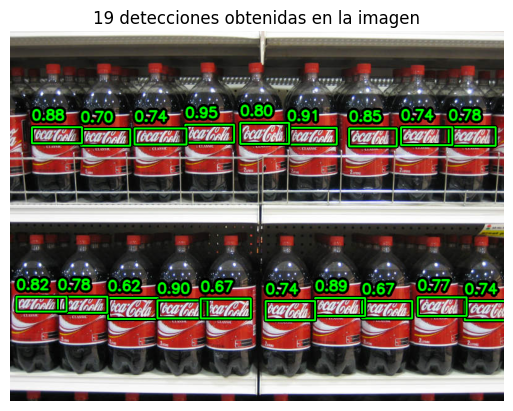

In [12]:
img_detections = img_multi.copy()

for detection in detections:
    # Dibujo de la bounding box (con contorno).
    cv2.rectangle(img_detections, detection[0], detection[1], (0, 0, 0), 6)
    cv2.rectangle(img_detections, detection[0], detection[1], (0, 255, 0), 2)

    # Dibujo del texto con el valor (con contorno).
    text = f"{detection[2]:.2f}"
    cv2.putText(img_detections, text, (detection[0][0], detection[0][1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 0, 0), 10, cv2.LINE_AA)
    cv2.putText(img_detections, text, (detection[0][0], detection[0][1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2, cv2.LINE_AA)

plt_imshow(cv2.cvtColor(img_detections, cv2.COLOR_BGR2RGB), f"{len(detections)} detecciones obtenidas en la imagen")

Se puede concluir a partir del resultado observado que los 19 logos se encontraron con éxito.

<br>

A pesar de ello, el algoritmo escrito sigue sin ser ideal en tanto que continúa habiendo dependencia de los parámetros (por ejemplo, se requiere conocer en forma aproximada el radio del círculo que envuelve una instancia). Las posibles mejoras al mismo apuntarían a una detección inteligente del radio o posición ideal del círculo de centrado sin que sea necesario especificarlo, o algún tipo de proceso que pruebe con distintos valores para aprender automáticamente los parámetros óptimos.

## **3.** Aplicación del Algoritmo con SIFT a las Imágenes Restantes

Se procede a probar, en fin, la misma función de detección sobre las imágenes restantes, esperando que, al haber en ellas una única instancia dominante, el algoritmo resuelva las detecciones rápidamente y en un solo intento por imagen.

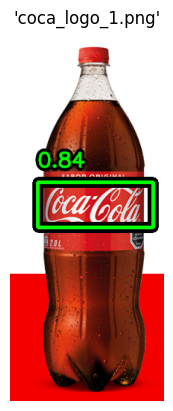

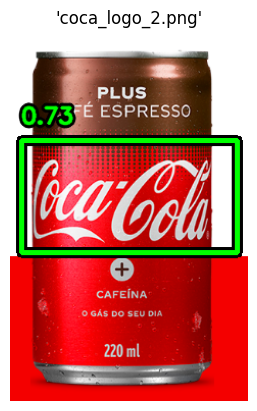

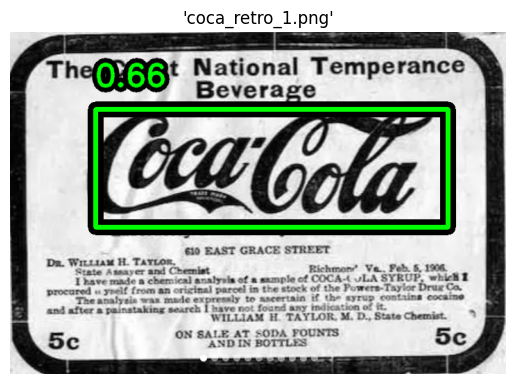

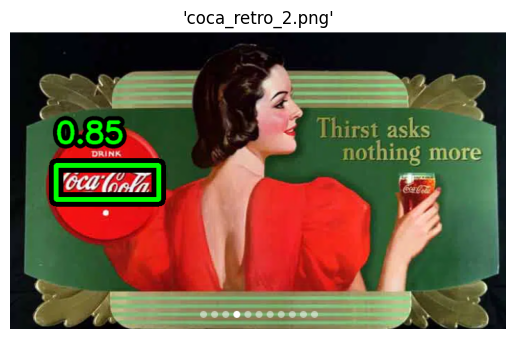

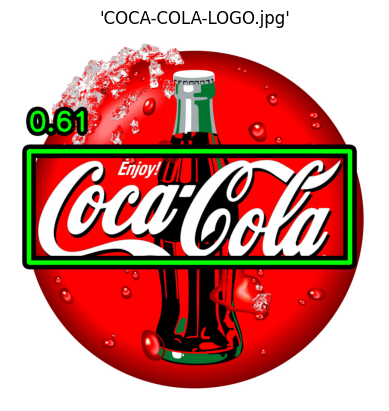

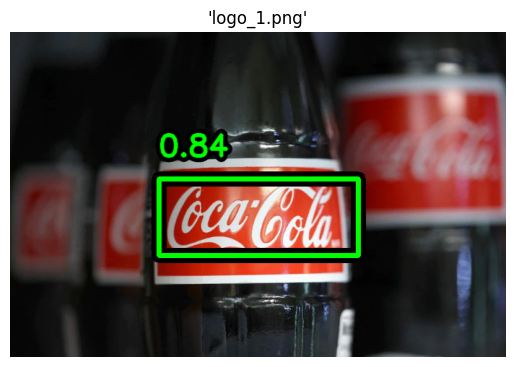

In [13]:
# Iteramos sobre cada imagen restante.
# En el caso de 'coca_retro_1' se usa el template no invertido.

for img_name in img_list[:-1]:
    if img_name == 'images/coca_multi.png':
        continue # Ya la procesamos en el bloque anterior.

    img = cv2.imread(img_name, cv2.IMREAD_COLOR)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Dimensiones de la imagen.
    h_img, w_img = img_gray.shape
    diag_img = int(np.sqrt(w_img**2 + h_img**2))

    if img_name == 'images/coca_retro_1.png':
        # Para esta imagen en concreto, usamos el template original (no invertido).
        template = img_template_gray.copy()
    else:
        template = img_template_gray_neg.copy()

    # Parámetros que funcionan: 1 intento máximo, radio=irrelevante, ratio de Lowe=0.75, factor de división para el margen=20.
    detections = sift_object_detector(template, img_gray, 1, None, 0.75, 20)

    img_detections = img.copy()

    for detection in detections:
        w_bbox = np.abs(detection[0][0] - detection[1][0])

        # Dibujo de la bounding box (con contorno).
        cv2.rectangle(img_detections, detection[0], detection[1], (0, 0, 0), int(diag_img / 40))
        cv2.rectangle(img_detections, detection[0], detection[1], (0, 255, 0), int(diag_img / 130))

        # Dibujo del texto con el valor (con contorno).
        text = f"{detection[2]:.2f}"
        cv2.putText(img_detections, text, (detection[0][0], detection[0][1] - int(diag_img / 25)), cv2.FONT_HERSHEY_SIMPLEX, diag_img / 600, (0, 0, 0), int(diag_img / 50), cv2.LINE_AA)
        cv2.putText(img_detections, text, (detection[0][0], detection[0][1] - int(diag_img / 25)), cv2.FONT_HERSHEY_SIMPLEX, diag_img / 600, (0, 255, 0), int(diag_img / 200), cv2.LINE_AA)

    plt_imshow(cv2.cvtColor(img_detections, cv2.COLOR_BGR2RGB), f"'{img_name[7:]}'")

    print("")

Habiendo explorado tanto **template matching** como la extracción y correspondencia de características locales con **SIFT** como vías posibles para efectuar las detecciones, se concluye que se cumplieron los objetivos propuestos (véanse las imágenes que presentan cada resultado).